<a href="https://colab.research.google.com/github/EzeGB/PythonExcercises/blob/practica3/practica3DiplomadoCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔹 Ejercicio 1: Distribución Binomial

Se lanza una moneda cuatro veces consecutivas:
* Mostrar en pantalla todas las combinaciones posibles de obtener cara dos veces.
* Calcular la probabilidad de que se obtenga cara al menos una vez.
* Generar un gráfico de la distribución probabilística.


Creamos una permutadora para 2 valores, asi obtenemos los valores posibles de resultados por cada n lanzamientos.

In [ ]:
def permutadora(n):
    if n == 1:
        return [[0], [1]]
    else:
        resultado = []
        preliminares = permutadora(n-1)

        for x in preliminares:
            for z in [0, 1]:
                x.append(z)
                resultado.append(list(x))
                x.pop()
        return resultado

In [ ]:
resultadoPermutado = permutadora(4)
print(resultadoPermutado)

[[0, 0, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0], [0, 0, 1, 1], [0, 1, 0, 0], [0, 1, 0, 1], [0, 1, 1, 0], [0, 1, 1, 1], [1, 0, 0, 0], [1, 0, 0, 1], [1, 0, 1, 0], [1, 0, 1, 1], [1, 1, 0, 0], [1, 1, 0, 1], [1, 1, 1, 0], [1, 1, 1, 1]]


Mapeamos las posibilidades

In [ ]:
posibilidades = []
for indice,posibilidad in enumerate(resultadoPermutado):
    posibilidades.append('')
    for p in posibilidad:
        if p == 0:
            posibilidades[indice] += 'T' #Tails para cruz
        else:
            posibilidades[indice] += 'H' #heads para cara
print(posibilidades)

['TTTT', 'TTTH', 'TTHT', 'TTHH', 'THTT', 'THTH', 'THHT', 'THHH', 'HTTT', 'HTTH', 'HTHT', 'HTHH', 'HHTT', 'HHTH', 'HHHT', 'HHHH']


Imprimimos las posibilidades:

In [ ]:
print('Combinaciones para obtener cara (H) exactamente 2 veces')
for p in posibilidades:
    if p.count('H') == 2:
        print(p)

Combinaciones para obtener cara (H) exactamente 2 veces
TTHH
THTH
THHT
HTTH
HTHT
HHTT


Calcular la probabilidad de que se obtenga cara al menos una vez.

In [ ]:
from scipy.stats import binom
bin = binom(4, 0.5) #Cuatro lanzamientos, cada uno con 50% de sacar exito (H)
bin.cdf(4) - bin.cdf(0) ##Al menos una vez (o mas) menos las posibilidades de que no salga cara

np.float64(0.9375)

Generar un gráfico de la distribución probabilística.

<BarContainer object of 5 artists>

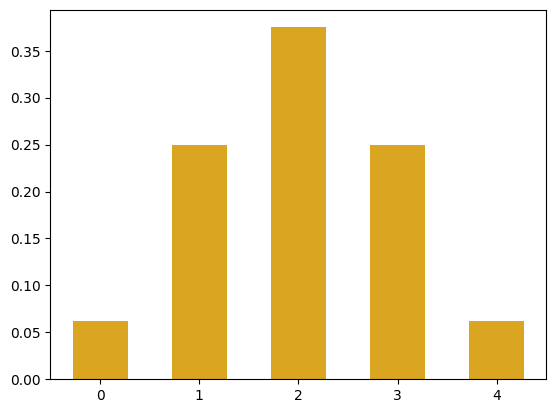

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

h = np.arange(0, 4 + 1)
prob = [bin.pmf(h) for h in h]

plt.bar(h, prob, width=0.55, color='goldenrod')

🔹 Ejercicio 2: Distribución de Poisson

Un cajero atiende a 5 clientes en un tiempo de 30 minutos. Se pide:

* Calcular la probabilidad de que al menos se atiendan a 3 clientes en 15 minutos
* Calcular la probabilidad de atender como máximo 6 clientes en 10 minutos.
* Generar el gráfico de la distribución de probabilidad con una media de 30 minutos, y luego comparar con media de 10 y 20 minutos.


Se importa la libreria y se observa la prob que atienda a 5 clientes en 30 min.

In [4]:
from scipy.stats import poisson
media_30_min = 5
poi30 = poisson(media_30_min)
poi30.cdf(5)

np.float64(0.615960654833063)

In [7]:
poi15 = poisson(media_30_min/2)
print('Al menos 3 clientes en 15 min:',(1 - poi15.cdf(3)))

Al menos 3 clientes en 15 min: 0.24242386686693385


In [16]:
poi10 = poisson(media_30_min/3)
print('Maximo 6 clientes en 10 min:',poi10.cdf(6))

Maximo 6 clientes en 10 min: 0.998320624390836


Grafico de mu 5 clientes en 30 min

<BarContainer object of 16 artists>

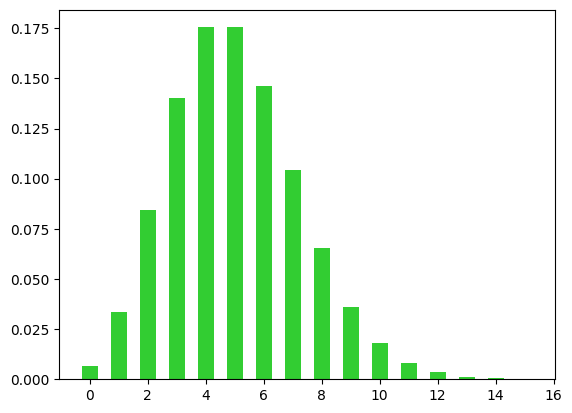

In [20]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange (0, 15 +1)
y30 = [poi30.pmf(x) for x in x]

plt.bar(x, y30, width=0.55, color='limegreen')

Grafico de mu de 3.333 (10/3) clientes en 20 min

<BarContainer object of 16 artists>

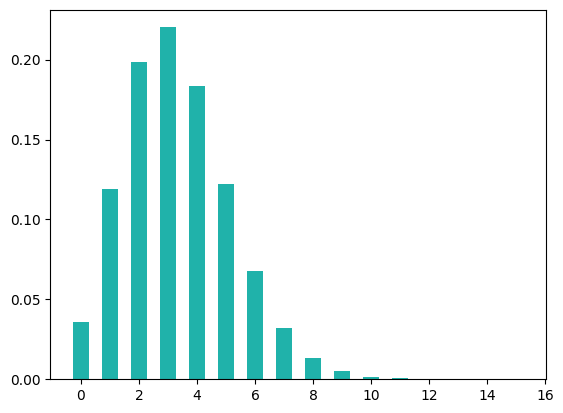

In [23]:
poi20 = poisson(media_30_min*(2/3))

y20 = [poi20.pmf(x) for x in x]
plt.bar(x, y20, width = 0.55, color = 'lightseagreen')

Grafico de mu 1.666 (5/3) clientes en 10 min

<BarContainer object of 16 artists>

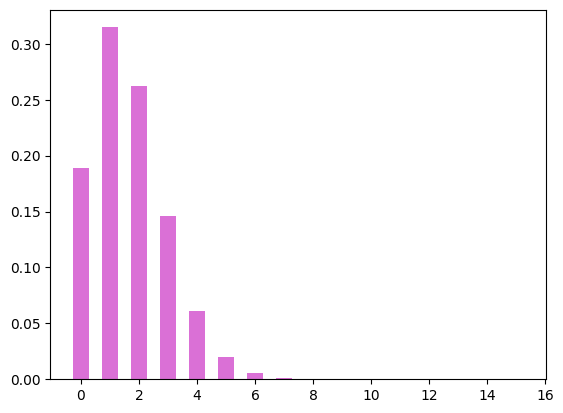

In [25]:
y10 = [poi10.pmf(x) for x in x]
plt.bar(x, y10, width = 0.55, color = 'orchid')

🔹 Ejercicio 3: Distribución Uniforme

El tiempo de espera por el autobus tiene una distribución uniforme entre 10 y 15 minutos. Se pide:

* Generar el gráfico de la distribución
* Calcular la media
* Calcular la probabilidad de que la espera sea mayor a 12 minutos
* Calcular la probabilidad de que la espera esté entre 11 y 13 minutos
